# 1. Overview & Objectives
## Time Series Forecasting - Final check of our predictions vs actual data

This notebook **trains** our selected **best model (GRU)** and **visualizes**:  
- Forecast period with the actual data and predictions of the best model.

Furthermore, it contains the **new data aquisition and preparation pipeline**.  
- Context to that: the used website for this project underwent major changes and is not available anymore.   
  The new website of the `meteostat data` can be found under:   
  - https://dev.meteostat.net/   
- Becuase of the library updates and changes of the dataframes we had to include some additional preprocessing steps to read in the latest data records and compare them to our predictions.

# 2. Imports & Setup

In [1]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "ensurepip", "--upgrade"]) #ensure pip is installed

0

In [2]:
#install meteostat package
!"{sys.executable}" -m pip install meteostat 

  Attempting uninstall: pytz
    Found existing installation: pytz 2025.2
    Uninstalling pytz-2025.2:
      Successfully uninstalled pytz-2025.2



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from datetime import datetime
import matplotlib.pyplot as plt

import pandas as pd

In [4]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# 3. Load Data from website

In [5]:
import meteostat as ms

In [6]:
# Get nearby weather stations
POINT = ms.Point(44.182205, -84.506836, 300)
stations = ms.stations.nearby(POINT, limit=8)

# Print DataFrame
print(stations)

                                            name country region  latitude  \
id                                                                          
72638                   Roscommon County Airport      US     MI   44.3500   
KY310  West Branch / Twin Pines Mobile Home Park      US     MI   44.2448   

       longitude  elevation         timezone  distance  
id                                                      
72638   -84.6667        351  America/Detroit   22586.7  
KY310   -84.1798        269  America/Detroit   26977.6  


### Load weather data 

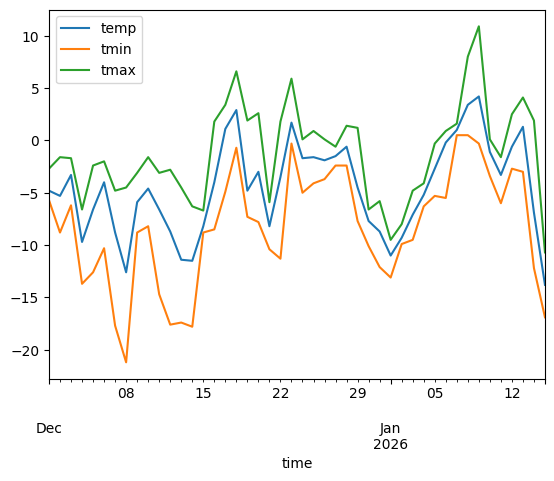

In [7]:
# Set time period
START = datetime(2025, 12, 1)
END = datetime(2026, 1, 16)


# Get daily data
data = ms.daily(stations, START, END)
df = ms.interpolate(data, POINT).fetch()

df.plot(y=[ms.Parameter.TEMP, ms.Parameter.TMIN, ms.Parameter.TMAX])
plt.show()

In [8]:
df.describe()

,temp,tmin,tmax,rhum,prcp,snwd,wspd,wpgt,pres,cldc
count,46.0,46.0,46.0,46.0,46.0,41.0,46.0,1.0,44.0,46.0
mean,-4.55,-8.28913,-1.186957,82.478261,2.078261,18.219512,13.03913,41.0,1012.402273,6.608696
std,4.436803,5.475003,4.53743,8.043601,3.195825,7.226729,5.168343,<NA>,7.654775,1.021508
min,-13.8,-21.2,-10.7,64.0,0.0,0.0,3.9,41.0,997.9,4.0
25%,-8.075,-11.9,-4.5,77.25,0.0,13.0,9.425,41.0,1008.325,6.0
50%,-4.55,-8.0,-1.6,82.0,0.5,20.0,12.35,41.0,1011.05,7.0
75%,-1.525,-4.3,1.75,87.75,2.4,23.0,15.7,41.0,1016.875,7.0
max,4.2,0.5,10.9,99.0,11.7,28.0,27.9,41.0,1026.1,8.0


### Sanity Check - Average Temperature Plot

In [9]:
# Plot function

def Plot(df, category, Title):
    #full_index = pd.date_range(start=start, end=end)
    df = df.copy()
    df.plot(y=[category])

    plt.xlabel('Date')
    plt.ylabel(Title)
    plt.title(f"{Title} for Michigan (2025-2026)")
    plt.show()

In [10]:
df.isna().sum()

temp     0
tmin     0
tmax     0
rhum     0
prcp     0
snwd     5
wspd     0
wpgt    45
pres     2
cldc     0
dtype: int64

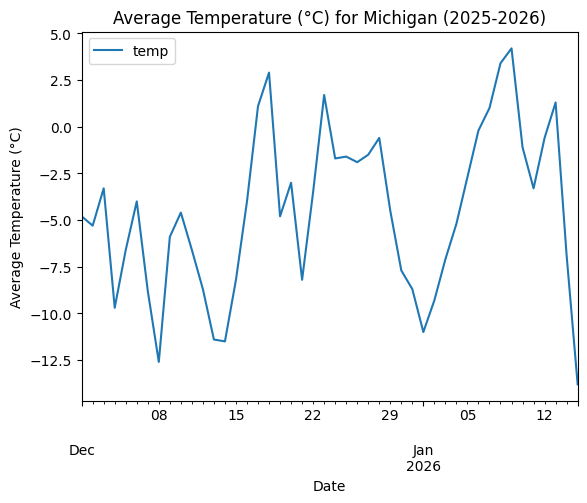

In [11]:
Plot(df, 'temp', 'Average Temperature (°C)')

## Plot Predictions vs. Actual Values

In [12]:
# renaming temp to tavg for concat
data = df['temp'].rename('tavg')
data

time
2025-12-01    -4.8
2025-12-02    -5.3
2025-12-03    -3.3
2025-12-04    -9.7
2025-12-05    -6.6
2025-12-06    -4.0
2025-12-07    -8.8
2025-12-08   -12.6
2025-12-09    -5.9
2025-12-10    -4.6
2025-12-11    -6.6
2025-12-12    -8.7
2025-12-13   -11.4
2025-12-14   -11.5
2025-12-15    -8.2
2025-12-16    -4.0
2025-12-17     1.1
2025-12-18     2.9
2025-12-19    -4.8
2025-12-20    -3.0
2025-12-21    -8.2
2025-12-22    -3.5
2025-12-23     1.7
2025-12-24    -1.7
2025-12-25    -1.6
2025-12-26    -1.9
2025-12-27    -1.5
2025-12-28    -0.6
2025-12-29    -4.5
2025-12-30    -7.7
2025-12-31    -8.7
2026-01-01   -11.0
2026-01-02    -9.3
2026-01-03    -7.1
2026-01-04    -5.2
2026-01-05    -2.7
2026-01-06    -0.2
2026-01-07     1.0
2026-01-08     3.4
2026-01-09     4.2
2026-01-10    -1.1
2026-01-11    -3.3
2026-01-12    -0.6
2026-01-13     1.3
2026-01-14    -6.9
2026-01-15   -13.8
Name: tavg, dtype: Float64

In [13]:
data.describe()

count        46.0
mean        -4.55
std      4.436803
min         -13.8
25%        -8.075
50%         -4.55
75%        -1.525
max           4.2
Name: tavg, dtype: Float64

In [14]:
data.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 46 entries, 2025-12-01 to 2026-01-15
Series name: tavg
Non-Null Count  Dtype  
--------------  -----  
46 non-null     Float64
dtypes: Float64(1)
memory usage: 782.0 bytes


In [16]:
preprocessed_data = pd.read_csv(r'C:\Public\TIS3IL-WS25-Project\data\processed\processed_weather_data_michigan.csv', index_col='time')

In [17]:
df_old = preprocessed_data.reset_index(drop=False)
df_new = data.reset_index(drop=False)

df_old["time"] = pd.to_datetime(df_old["time"])
df_new["time"] = pd.to_datetime(df_new["time"])

df_all = (
    pd.concat([df_old, df_new], ignore_index=True)
      .sort_values("time")
      .drop_duplicates(subset="time", keep="last")
      .reset_index(drop=True)
)

In [18]:
df_all

,time,tavg,tmin,tmax,prcp,snow,wspd
0,1980-01-01,-0.85,-2.8,1.1,0.0,2.000000,13.561500
1,1980-01-02,-3.9,-7.2,-0.6,0.0,2.000000,13.933889
2,1980-01-03,-8.85,-13.3,-4.4,0.0,2.000000,13.908000
3,1980-01-04,-10.3,-16.7,-3.9,0.0,3.857143,14.128556
4,1980-01-05,-7.5,-12.8,-2.2,0.0,5.000000,15.247333
...,...,...,...,...,...,...,...
16809,2026-01-11,-3.3,NaN,NaN,NaN,NaN,NaN
16810,2026-01-12,-0.6,NaN,NaN,NaN,NaN,NaN
16811,2026-01-13,1.3,NaN,NaN,NaN,NaN,NaN
16812,2026-01-14,-6.9,NaN,NaN,NaN,NaN,NaN


# 4. Future Forecast for December and January

##### Imports and Setup

In [19]:
import import_ipynb
import sys
sys.path.append("code")

from splitting import split_time_series
from metrics import load_best_models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [20]:
from neuralforecast.models import GRU

#Torch (for reproducibility)
import torch
torch.manual_seed(42)

In [21]:
splits = split_time_series(
    csv_path="../data/processed/processed_weather_data_michigan.csv",
    date_col="time",
    y_col="tavg",
    train_end="2015-12-31",
    val_end="2020-12-31",
    test_end="2025-11-30",
    start_date="1980-01-01",
    end_date="2026-01-16"
)

train_df = splits["train"]
val_df   = splits["val"]
test_df  = splits["test"]

h_val  = len(val_df)
h_test = len(test_df)

#### Neural Results

In [22]:
def to_nixtla_format(df, uid="series_1"):
    out = df.rename(columns={"time": "ds", "tavg": "y"}).copy()
    out["unique_id"] = uid
    return out[["unique_id", "ds", "y"]]

In [23]:
from neuralforecast import NeuralForecast
from neuralforecast.models import GRU
from neuralforecast.losses.pytorch import MAE

def run_neural_gru_forecast(train_df, val_df, test_df):
    #Convert data
    train_nf = to_nixtla_format(train_df)
    val_nf   = to_nixtla_format(val_df)
    test_nf  = to_nixtla_format(test_df)

    INPUT_SIZE = 365
    MAX_STEPS  = 500

    #Validation
    H_VAL = len(val_nf)

    gru_val = GRU(
        h=H_VAL,
        input_size=INPUT_SIZE,
        encoder_hidden_size=64,
        encoder_n_layers=2,
        decoder_hidden_size=64,
        decoder_layers=2,
        loss=MAE(),
        max_steps=MAX_STEPS
    )

    nf_val = NeuralForecast(
        models=[gru_val],
        freq="D"
    )

    nf_val.fit(train_nf)
    val_forecast = nf_val.predict()

    val_pred = val_forecast.iloc[:, 2].values #GRU output

    #Test
    H_TEST = len(test_nf)

    gru_test = GRU(
        h=H_TEST,
        input_size=INPUT_SIZE,
        encoder_hidden_size=64,
        encoder_n_layers=2,
        decoder_hidden_size=64,
        decoder_layers=2,
        loss=MAE(),
        max_steps=MAX_STEPS
    )

    nf_test = NeuralForecast(
        models=[gru_test],
        freq="D"
    )

    train_val_nf = pd.concat([train_nf, val_nf])
    nf_test.fit(train_val_nf)

    test_forecast = nf_test.predict()
    test_pred = test_forecast.iloc[:, 2].values

    return {
        "model_family": "Neural",
        "model_name": "GRU",
        "params": {
            "input_size": INPUT_SIZE,
            "encoder_hidden_size": 64,
            "encoder_n_layers": 2,
            "decoder_hidden_size": 64,
            "decoder_layers": 2,
            "loss": "MAE",
            "max_steps": MAX_STEPS
        },
        "val_pred": val_pred,
        "test_pred": test_pred
    }

#Running the NeuralForecast GRU model
neural_results = run_neural_gru_forecast(train_df, val_df, test_df)

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name              | Type          | Params | Mode 
------------------------------------------------------------
0 | loss              | MAE           | 0      | train
1 | padder_train      | ConstantPad1d | 0      | train
2 | scaler            | TemporalNorm  | 0      | train
3 | hist_encoder      | GRU           | 37.8 K | train
4 | mlp_decoder       | MLP           | 4.2 K  | train
5 | upsample_sequence | Linear        | 668 K  | train
------------------------------------------------------------
710 K     Trainable params
0         Non-trainable params
710 K     Total params
2.843     Total estimated model params size (MB)
11        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=500` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

# 5. Visualizations

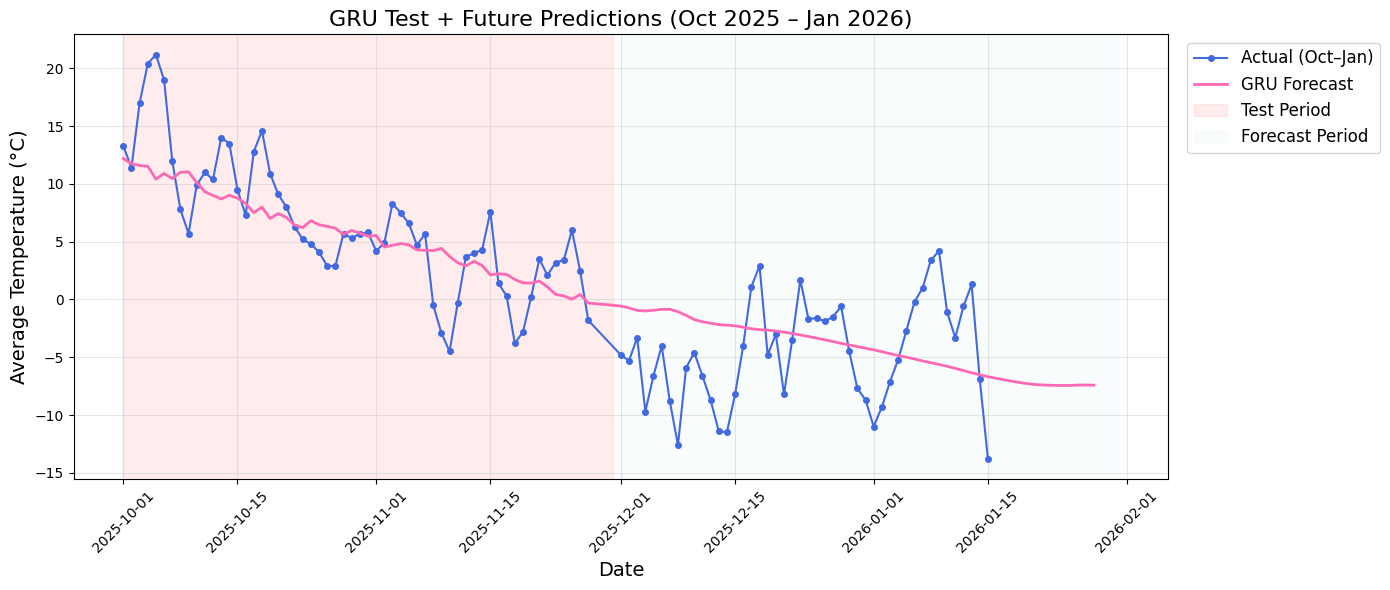

In [33]:
#Load future predictions
future_pred = pd.read_parquet("../data/models/best_neural_forecast_dec_jan.parquet", engine="fastparquet")

#Filter actual test data for October–November
test_oct_nov = df_all[(df_all['time'] >= "2025-10-01") & (df_all['time'] <= "2026-01-16")]

#Example if column is 'index' instead of 'ds'
if 'date' in future_pred.columns:
    future_pred = future_pred.rename(columns={'date': 'ds'})

#Ensure it's datetime
future_pred['ds'] = pd.to_datetime(future_pred['ds'])


#Get corresponding GRU test predictions for Oct–Nov
test_pred_series = pd.Series(neural_results['test_pred'], index=test_df['time'])
test_pred_oct_nov = test_pred_series.loc["2025-10-01":"2025-11-30"]

#Combine test predictions with future predictions (Dec–Jan)
#Convert index to Series before concatenation
combined_dates = pd.concat([pd.Series(test_pred_oct_nov.index), future_pred['ds']])
combined_values = pd.concat([pd.Series(test_pred_oct_nov.values), future_pred['y_pred']])

#Plot
plt.figure(figsize=(14, 6))

#Actual data for Oct–Jan
plt.plot(test_oct_nov['time'], test_oct_nov['tavg'], '-o', color='royalblue', markersize=4, label='Actual (Oct–Jan)')

#GRU forecast (test + future)
plt.plot(combined_dates, combined_values, '-', color='hotpink', linewidth=2, label='GRU Forecast')

#highlight Oct–Nov and Dec–Jan periods
plt.axvspan("2025-10-01", "2025-11-30", color='red', alpha=0.07, label="Test Period")
plt.axvspan("2025-12-01", "2026-01-31", color='lightblue', alpha=0.07, label="Forecast Period")

#Labels, grid, and legend
plt.xlabel("Date", fontsize=14)
plt.ylabel("Average Temperature (°C)", fontsize=14)
plt.title("GRU Test + Future Predictions (Oct 2025 – Jan 2026)", fontsize=16)
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)

#X-axis formatting
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

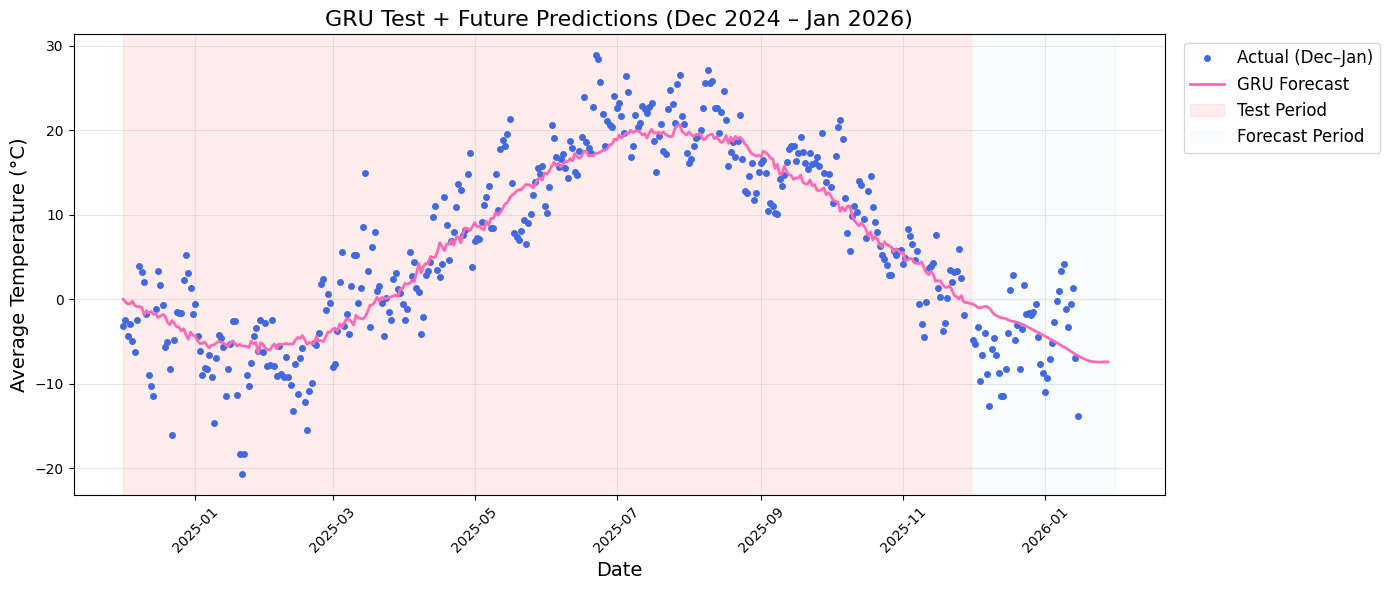

In [29]:
#Load future predictions
future_pred = pd.read_parquet("../data/models/best_neural_forecast_dec_jan.parquet", engine="fastparquet")

#Filter actual test data for December–January
test_dec_jan = df_all[(df_all['time'] >= "2024-12-01") & (df_all['time'] <= "2026-01-16")]

#Example if column is 'index' instead of 'ds'
if 'date' in future_pred.columns:
    future_pred = future_pred.rename(columns={'date': 'ds'})

#Ensure it's datetime
future_pred['ds'] = pd.to_datetime(future_pred['ds'])


#Get corresponding GRU test predictions for Dec–Nov
test_pred_series = pd.Series(neural_results['test_pred'], index=test_df['time'])
test_pred_dec_nov = test_pred_series.loc["2024-12-01":"2025-11-30"]

#Combine test predictions with future predictions (Dec–Jan)
#Convert index to Series before concatenation
combined_dates = pd.concat([pd.Series(test_pred_dec_nov.index), future_pred['ds']])
combined_values = pd.concat([pd.Series(test_pred_dec_nov.values), future_pred['y_pred']])


#Plot
plt.figure(figsize=(14, 6))

#Actual data for Dec–Jan
plt.plot(test_dec_jan['time'], test_dec_jan['tavg'], 'o', color='royalblue', markersize=4, label='Actual (Dec–Jan)')

#GRU forecast (test + future)
plt.plot(combined_dates, combined_values, '-', color='hotpink', linewidth=2, label='GRU Forecast')

#highlight Dec–Nov and Dec–Jan periods
plt.axvspan("2024-12-01", "2025-11-30", color='red', alpha=0.07, label="Test Period")
plt.axvspan("2025-12-01", "2026-01-31", color='lightblue', alpha=0.07, label="Forecast Period")

#Labels, grid, and legend
plt.xlabel("Date", fontsize=14)
plt.ylabel("Average Temperature (°C)", fontsize=14)
plt.title("GRU Test + Future Predictions (Dec 2024 – Jan 2026)", fontsize=16)
plt.grid(alpha=0.3)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=12)

#X-axis formatting
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 6. Metrics evaluation on the final predictions

In [36]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

#Prepare a DataFrame for the combined predictions
pred_df = pd.DataFrame({
    'time': combined_dates.values,
    'y_pred': combined_values.values
})

#Merge actuals and predictions on the time column to ensure alignment
#inner join to only include dates present in both datasets
eval_df = pd.merge(test_dec_jan[['time', 'tavg']], pred_df, on='time', how='inner')

#Define metrics
y_true = eval_df['tavg']
y_pred = eval_df['y_pred']

def calculate_metrics(actual, pred):
    mae = mean_absolute_error(actual, pred)
    mse = mean_squared_error(actual, pred)
    rmse = np.sqrt(mse)
    ope = (np.sum(pred) - np.sum(actual)) / np.sum(actual) * 100
    r2 = r2_score(actual, pred)
    
    return {
        "MAE": mae,
        "RMSE": rmse,
        "OPE (%)": ope,
        "R²": r2,
        "Datapoints": len(actual)
    }


metrics = calculate_metrics(y_true, y_pred)

print(f"Metrics for Dec - Jan 16 (Points: {metrics['Datapoints']}):")
for k, v in metrics.items():
    if k != "Datapoints":
        print(f"{k}: {v:.4f}")

Metrics for Dec - Jan 16 (Points: 104):
MAE: 3.6102
RMSE: 4.5478
OPE (%): 8.8167
R²: 0.6344


### Interpretation of the final results
|Metric|Value|Rating|Description|
|----|----|----|----|
MAE|3.6102|Good|**Mean Absolute Error:** On average, the predictions are off by ~3.6°C. For Michigan's volatile winter, this is a solid result.|
RMSE|4.5478|Fair|**Root Mean Square Error:** Higher than MAE, indicating the model occasionally makes larger errors (e.g. missing a sudden cold snap).|
R²|0.6344|Good|**Coefficient of Determination:** The model explains ~63% of the temperature variance. It has captured the seasonal trend well.|
OPE|8.8167%|Fair|**Overall Percentage Error:** A positive value indicates a "Warm Bias." The model is generally predicting slightly warmer than the actual reality.|